In [3]:
!pip install -q riskfolio-lib==6.2.3

In [4]:
import riskfolio as rp

print(rp.__version__)

6.2.3


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[**************        30%                       ]  3 of 10 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[**********************50%                       ]  5 of 10 completed/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and 

Price Data:


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,PG,XOM
Date,,,,,,,,,,
2018-01-02,40.232384,59.450500,53.188862,110.130821,85.516029,35.024227,78.552010,4.922529,71.745117,57.811153
2018-01-03,40.225372,60.209999,54.096321,111.182861,85.603172,34.947323,78.917603,5.246500,71.658081,58.946583
2018-01-04,40.412220,60.479500,54.306454,111.174950,86.829475,35.439526,79.612167,5.274155,72.164589,59.028168
2018-01-05,40.872330,61.457001,55.026569,112.092491,86.272057,35.431843,80.599228,5.318852,72.212097,58.980572
2018-01-08,40.720528,62.343498,55.220840,112.234863,86.399475,35.378006,80.681473,5.481824,72.591988,59.245708


Returns:


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,PG,XOM
Date,,,,,,,,,,
2018-01-03,-0.000174,0.012775,0.017061,0.009553,0.001019,-0.002196,0.004654,0.065814,-0.001213,0.019640
2018-01-04,0.004645,0.004476,0.003884,-0.000071,0.014325,0.014084,0.008801,0.005271,0.007068,0.001384
2018-01-05,0.011385,0.016163,0.013260,0.008253,-0.006420,-0.000217,0.012398,0.008475,0.000658,-0.000806
2018-01-08,-0.003714,0.014425,0.003530,0.001270,0.001477,-0.001519,0.001020,0.030640,0.005261,0.004495
2018-01-09,-0.000115,0.004676,-0.001274,0.015857,0.005069,0.005000,-0.000679,-0.000270,-0.007305,-0.004246


NCO Portfolio Weights:


,weights
AAPL,3.125748e-02
AMZN,8.681749e-03
GOOGL,2.747084e-02
JNJ,3.019957e-01
JPM,4.809316e-02
KO,2.832167e-01
MSFT,4.907047e-02
NVDA,4.544420e-11
PG,2.094607e-01
XOM,4.075317e-02


,NCO Weight
JNJ,3.019957e-01
KO,2.832167e-01
PG,2.094607e-01
MSFT,4.907047e-02
JPM,4.809316e-02
XOM,4.075317e-02
AAPL,3.125748e-02
GOOGL,2.747084e-02
AMZN,8.681749e-03
NVDA,4.544420e-11


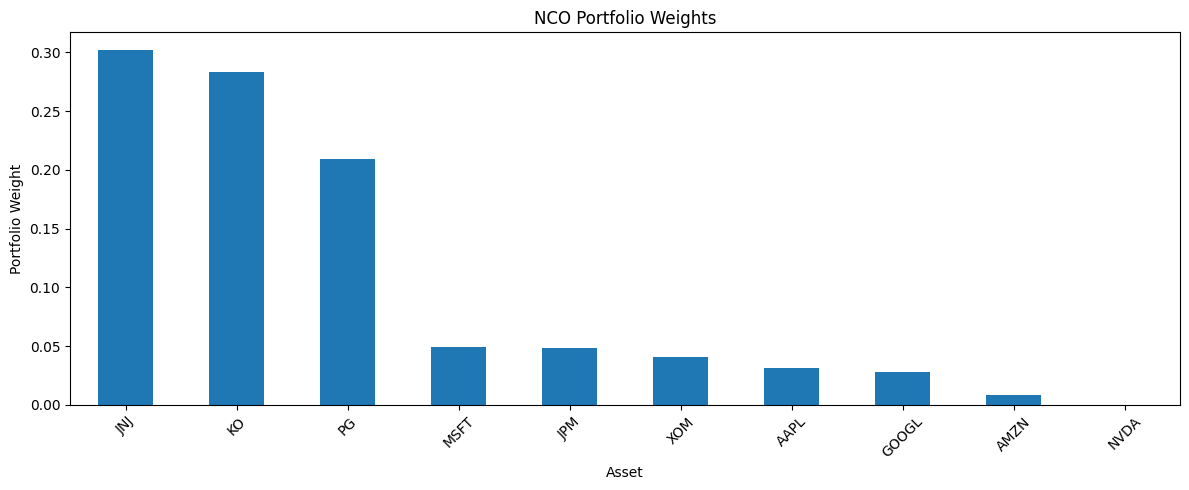


========== NCO PERFORMANCE ==========
Annual Return      : 12.73%
Annual Volatility  : 15.97%
Sharpe Ratio       : 0.797
Maximum Drawdown   : -30.30%


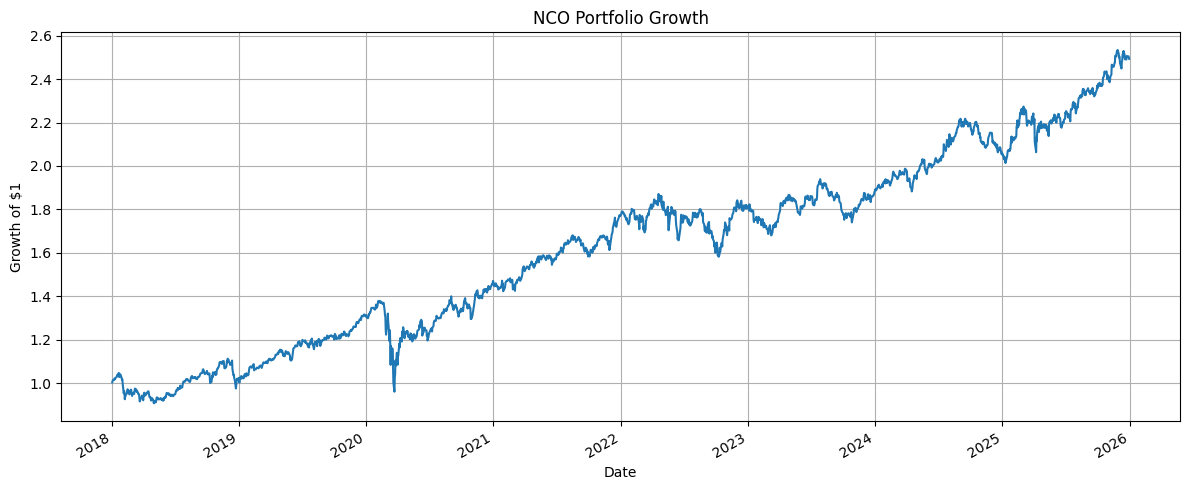

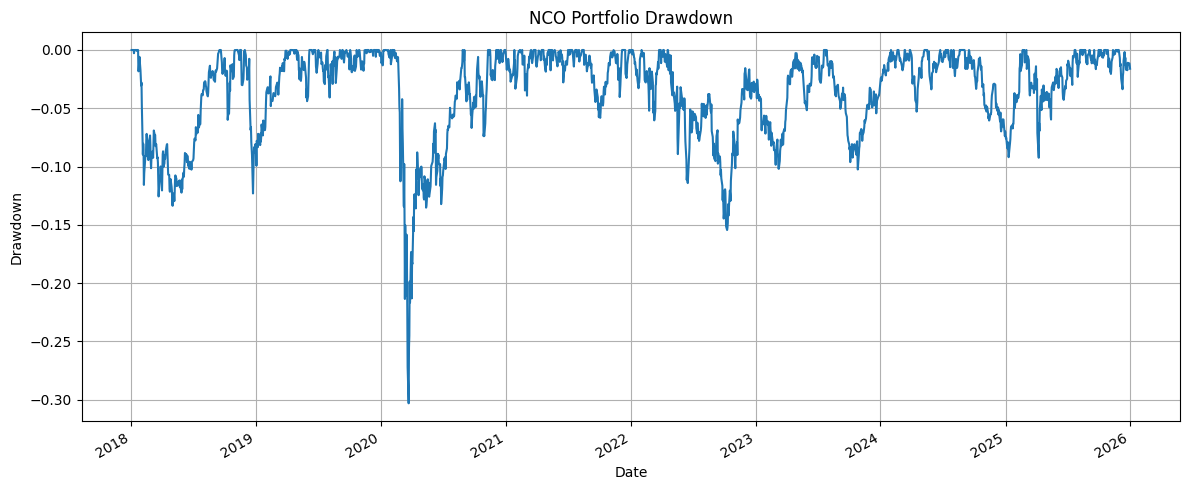

In [5]:
# ============================================================
# NCO (Nested Clustered Optimization) Portfolio
# ============================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import riskfolio as rp


# ============================================================
# 2. ASSET UNIVERSE
# ============================================================

tickers = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "JPM",
    "XOM",
    "JNJ",
    "PG",
    "KO"
]


# ============================================================
# 3. DOWNLOAD HISTORICAL PRICE DATA
# ============================================================

prices = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

print("Price Data:")
display(prices.head())


# ============================================================
# 4. CALCULATE DAILY RETURNS
# ============================================================

returns = prices.pct_change().dropna()

print("Returns:")
display(returns.head())


# ============================================================
# 5. CREATE HIERARCHICAL PORTFOLIO
# ============================================================

port = rp.HCPortfolio(
    returns=returns
)


# ============================================================
# 6. NCO OPTIMIZATION
# ============================================================

w_nco = port.optimization(
    model="NCO",
    codependence="pearson",
    rm="MV",
    linkage="ward",
    obj="MinRisk"
)


# ============================================================
# 7. DISPLAY NCO WEIGHTS
# ============================================================

print("NCO Portfolio Weights:")

display(w_nco)


# ============================================================
# 8. CLEAN WEIGHT TABLE
# ============================================================

weights = w_nco.copy()

# Identify the weight column automatically
weight_column = weights.columns[0]

weights = weights.rename(
    columns={weight_column: "NCO Weight"}
)

weights = weights.sort_values(
    "NCO Weight",
    ascending=False
)

display(weights)


# ============================================================
# 9. PLOT NCO WEIGHTS
# ============================================================

weights["NCO Weight"].plot(
    kind="bar",
    figsize=(12, 5),
    title="NCO Portfolio Weights"
)

plt.ylabel("Portfolio Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 10. CALCULATE PORTFOLIO RETURNS
# ============================================================

w = w_nco.iloc[:, 0]

portfolio_returns = returns @ w


# ============================================================
# 11. ANNUALIZED RETURN
# ============================================================

annual_return = (
    portfolio_returns.mean() * 252
)


# ============================================================
# 12. ANNUALIZED VOLATILITY
# ============================================================

annual_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)


# ============================================================
# 13. SHARPE RATIO
# ============================================================

sharpe_ratio = (
    annual_return / annual_volatility
)


# ============================================================
# 14. CUMULATIVE WEALTH
# ============================================================

wealth = (
    1 + portfolio_returns
).cumprod()


# ============================================================
# 15. MAXIMUM DRAWDOWN
# ============================================================

running_peak = wealth.cummax()

drawdown = (
    wealth / running_peak - 1
)

maximum_drawdown = drawdown.min()


# ============================================================
# 16. DISPLAY PERFORMANCE
# ============================================================

print("\n========== NCO PERFORMANCE ==========")

print(
    f"Annual Return      : {annual_return:.2%}"
)

print(
    f"Annual Volatility  : {annual_volatility:.2%}"
)

print(
    f"Sharpe Ratio       : {sharpe_ratio:.3f}"
)

print(
    f"Maximum Drawdown   : {maximum_drawdown:.2%}"
)


# ============================================================
# 17. PORTFOLIO EQUITY CURVE
# ============================================================

plt.figure(figsize=(12, 5))

wealth.plot()

plt.title("NCO Portfolio Growth")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 18. DRAWDOWN CHART
# ============================================================

plt.figure(figsize=(12, 5))

drawdown.plot()

plt.title("NCO Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)

plt.tight_layout()
plt.show()

NCO OUT-OF-SAMPLE BACKTEST
WITH TRANSACTION COSTS
Annual Return        : 12.97%
Annual Volatility    : 16.10%
Sharpe Ratio         : 0.806
Maximum Drawdown     : -30.74%
Average Turnover     : 15.15%
Total Turnover       : 12.73
Total Transaction Cost: 1.27%


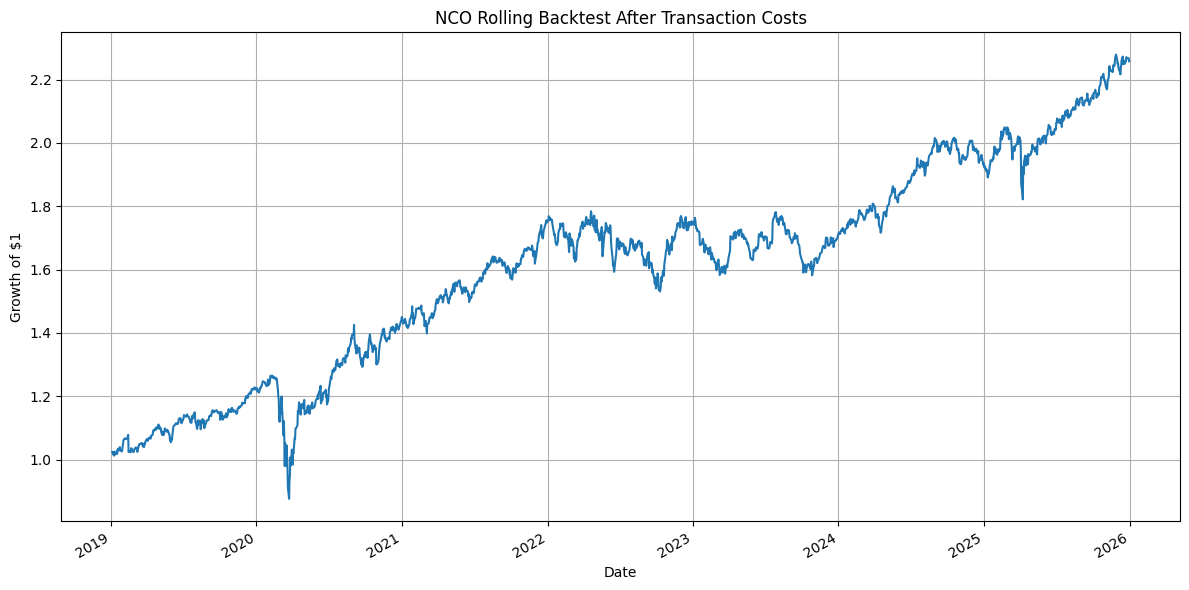

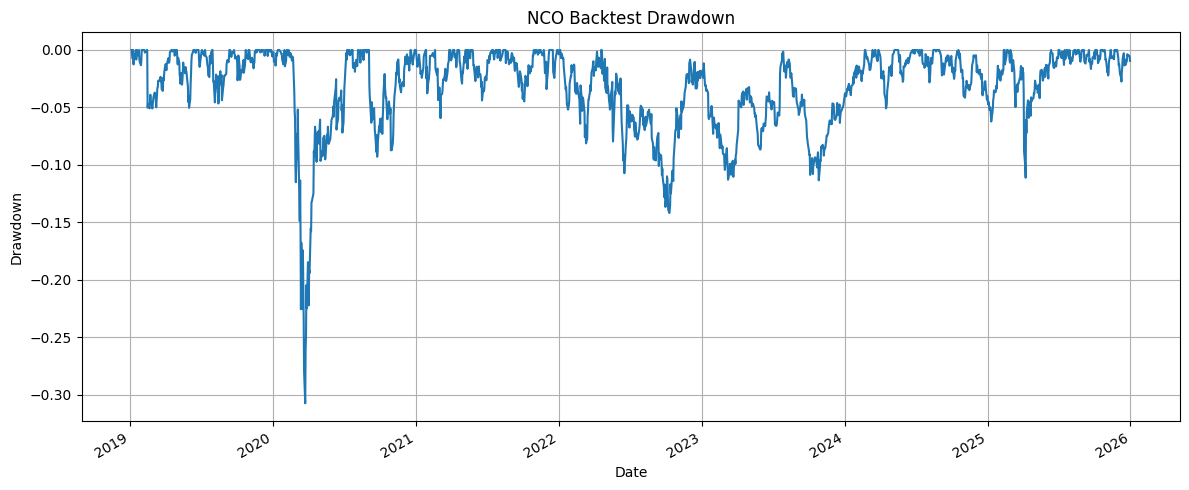

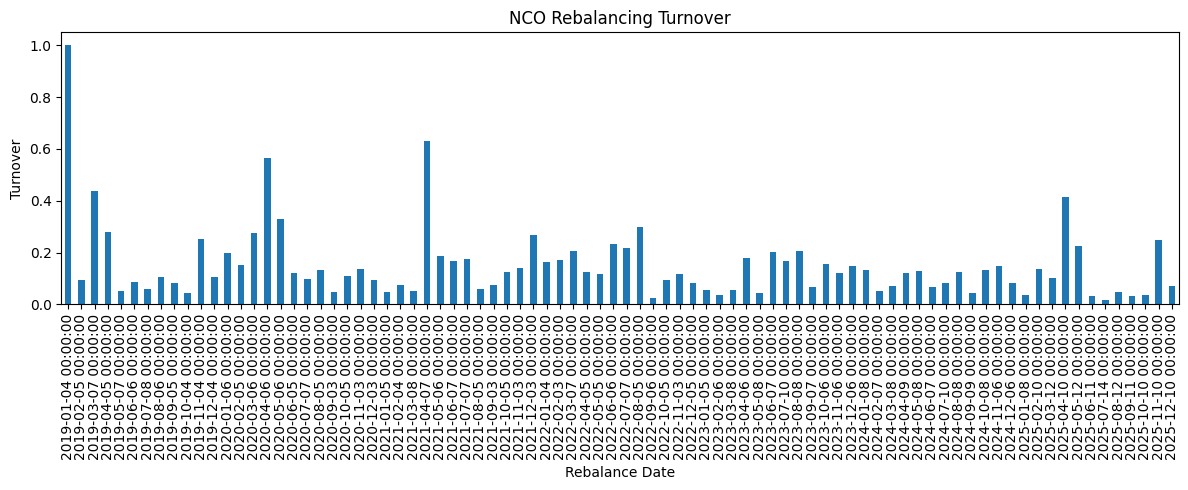

In [6]:
# ============================================================
# NCO ROLLING OUT-OF-SAMPLE BACKTEST
# WITH TURNOVER + TRANSACTION COSTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import riskfolio as rp


# ============================================================
# PARAMETERS
# ============================================================

training_window = 252
rebalance_frequency = 21

# One-way transaction cost
transaction_cost = 0.001     # 0.10%


# ============================================================
# STORAGE
# ============================================================

backtest_returns = []
weight_history = []

previous_weights = pd.Series(
    0.0,
    index=returns.columns
)


# ============================================================
# ROLLING NCO BACKTEST
# ============================================================

for start in range(
    training_window,
    len(returns),
    rebalance_frequency
):

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train = returns.iloc[
        start - training_window:start
    ]


    # --------------------------------------------------------
    # NCO OPTIMIZATION
    # --------------------------------------------------------

    port = rp.HCPortfolio(
        returns=train
    )

    weights = port.optimization(
        model="NCO",
        codependence="pearson",
        rm="MV",
        linkage="ward",
        obj="MinRisk"
    )


    # --------------------------------------------------------
    # ALIGN WEIGHTS
    # --------------------------------------------------------

    current_weights = weights.iloc[:, 0]

    current_weights = (
        current_weights
        .reindex(returns.columns)
        .fillna(0)
    )


    # --------------------------------------------------------
    # NORMALIZE WEIGHTS
    # --------------------------------------------------------

    if current_weights.sum() != 0:

        current_weights = (
            current_weights /
            current_weights.sum()
        )


    # --------------------------------------------------------
    # TURNOVER
    # --------------------------------------------------------

    turnover = (
        current_weights -
        previous_weights
    ).abs().sum()


    # --------------------------------------------------------
    # TRANSACTION COST
    # --------------------------------------------------------

    cost = turnover * transaction_cost


    # --------------------------------------------------------
    # STORE WEIGHTS
    # --------------------------------------------------------

    weight_history.append(
        pd.DataFrame(
            {
                "Weight": current_weights,
                "Turnover": turnover,
                "Transaction_Cost": cost
            }
        ).assign(
            Date=returns.index[start]
        )
    )


    # --------------------------------------------------------
    # OUT-OF-SAMPLE DATA
    # --------------------------------------------------------

    end = min(
        start + rebalance_frequency,
        len(returns)
    )

    test = returns.iloc[start:end]


    # --------------------------------------------------------
    # GROSS PORTFOLIO RETURNS
    # --------------------------------------------------------

    gross_returns = (
        test @ current_weights
    )


    # --------------------------------------------------------
    # APPLY TRANSACTION COST
    # --------------------------------------------------------

    net_returns = gross_returns.copy()

    # Apply cost on first day after rebalancing

    if len(net_returns) > 0:

        net_returns.iloc[0] = (
            net_returns.iloc[0] -
            cost
        )


    # --------------------------------------------------------
    # STORE RETURNS
    # --------------------------------------------------------

    backtest_returns.append(
        net_returns
    )


    # --------------------------------------------------------
    # UPDATE PREVIOUS WEIGHTS
    # --------------------------------------------------------

    previous_weights = current_weights.copy()


# ============================================================
# COMBINE RETURNS
# ============================================================

backtest_returns = pd.concat(
    backtest_returns
)

backtest_returns = (
    backtest_returns[
        ~backtest_returns.index.duplicated()
    ]
)


# ============================================================
# PERFORMANCE METRICS
# ============================================================

annual_return = (
    backtest_returns.mean() * 252
)

annual_volatility = (
    backtest_returns.std() *
    np.sqrt(252)
)

sharpe_ratio = (
    annual_return /
    annual_volatility
)


# ============================================================
# CUMULATIVE WEALTH
# ============================================================

wealth = (
    1 + backtest_returns
).cumprod()


# ============================================================
# MAXIMUM DRAWDOWN
# ============================================================

running_peak = wealth.cummax()

drawdown = (
    wealth /
    running_peak -
    1
)

maximum_drawdown = (
    drawdown.min()
)


# ============================================================
# TURNOVER HISTORY
# ============================================================

weight_history_df = pd.concat(
    weight_history
)

turnover_history = (
    weight_history_df
    .groupby("Date")["Turnover"]
    .first()
)


average_turnover = (
    turnover_history.mean()
)


total_turnover = (
    turnover_history.sum()
)


# ============================================================
# TOTAL TRANSACTION COST
# ============================================================

total_transaction_cost = (
    weight_history_df
    .groupby("Date")["Transaction_Cost"]
    .first()
    .sum()
)


# ============================================================
# RESULTS
# ============================================================

print("==============================================")
print("NCO OUT-OF-SAMPLE BACKTEST")
print("WITH TRANSACTION COSTS")
print("==============================================")

print(
    f"Annual Return        : {annual_return:.2%}"
)

print(
    f"Annual Volatility    : {annual_volatility:.2%}"
)

print(
    f"Sharpe Ratio         : {sharpe_ratio:.3f}"
)

print(
    f"Maximum Drawdown     : {maximum_drawdown:.2%}"
)

print(
    f"Average Turnover     : {average_turnover:.2%}"
)

print(
    f"Total Turnover       : {total_turnover:.2f}"
)

print(
    f"Total Transaction Cost: "
    f"{total_transaction_cost:.2%}"
)


# ============================================================
# EQUITY CURVE
# ============================================================

plt.figure(figsize=(12, 6))

wealth.plot()

plt.title(
    "NCO Rolling Backtest After Transaction Costs"
)

plt.ylabel("Growth of $1")

plt.xlabel("Date")

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# DRAWDOWN
# ============================================================

plt.figure(figsize=(12, 5))

drawdown.plot()

plt.title(
    "NCO Backtest Drawdown"
)

plt.ylabel("Drawdown")

plt.xlabel("Date")

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# TURNOVER
# ============================================================

plt.figure(figsize=(12, 5))

turnover_history.plot(
    kind="bar"
)

plt.title(
    "NCO Rebalancing Turnover"
)

plt.ylabel("Turnover")

plt.xlabel("Rebalance Date")

plt.tight_layout()

plt.show()